In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RAW = '../../data/raw'
OUT = '../../data/processed/combined_hourly.csv'
os.makedirs(os.path.dirname(OUT), exist_ok=True)

CONTINUOUS = ['load_mw', 'temperature_c', 'precipitation_mm',
              'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu']

In [29]:
def load(path, dt_col='datetime'):
    df = pd.read_csv(path)
    raw = df[dt_col].astype(str)
    if raw.str.contains(r'[+-]\d{2}:\d{2}$', regex=True).any():
        dt = pd.to_datetime(raw, utc=True).dt.tz_convert('America/Los_Angeles').dt.tz_localize(None)
    else:
        dt = pd.to_datetime(raw)
    df[dt_col] = dt
    return df.set_index(dt_col).sort_index()

caiso   = load(f'{RAW}/caiso_hourly.csv')
weather = load(f'{RAW}/weather_hourly.csv')
econ    = load(f'{RAW}/economic_hourly.csv')

In [30]:
df = caiso.join(weather, how='inner').join(econ, how='inner')

In [31]:
df[CONTINUOUS] = df[CONTINUOUS].interpolate(method='time', limit=6)
df[CONTINUOUS] = df[CONTINUOUS].ffill()

for col in CONTINUOUS:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

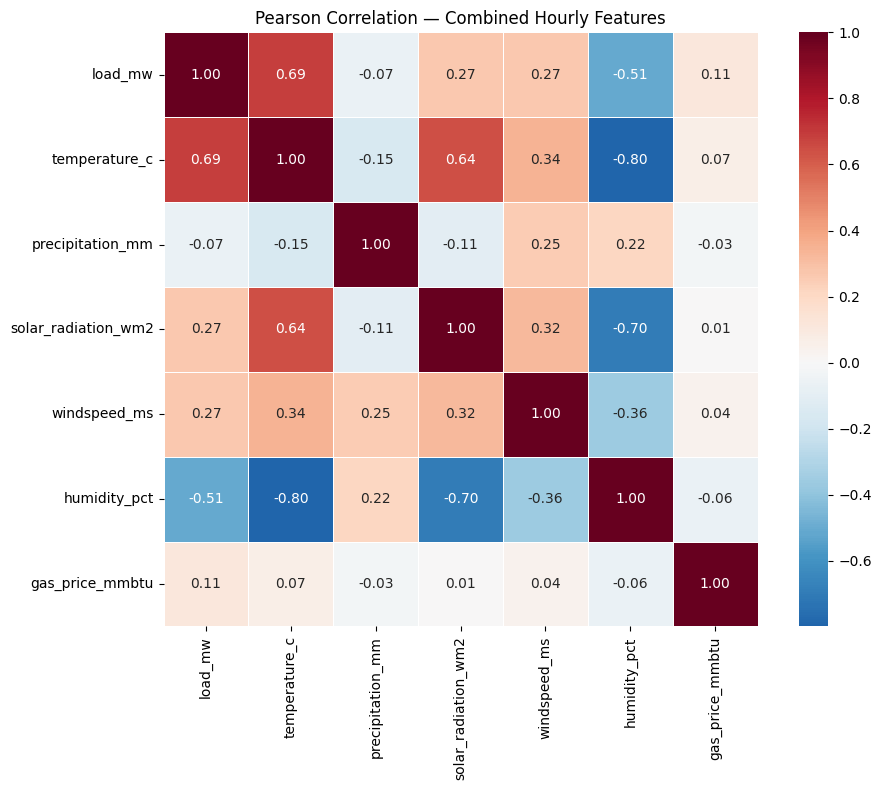

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[CONTINUOUS].corr(),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    square=True, linewidths=0.4, ax=ax
)
ax.set_title('Pearson Correlation — Combined Hourly Features')
plt.tight_layout()
plt.savefig('../../data/processed/correlation_heatmap.png')
plt.show()

In [33]:
df.to_csv(OUT)
print(f'Saved {len(df):,} rows × {len(df.columns)} columns → {OUT}')
print('Columns:', df.columns.tolist())

Saved 52,619 rows × 12 columns → ../../data/processed/combined_hourly.csv
Columns: ['load_mw', 'temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu', 'is_holiday', 'is_weekend', 'hour_of_day', 'day_of_week', 'month']
